# 02 · ASN / ISP Analysis

One row per country × ISP (Autonomous System) per month.

## What is an ASN?

The internet is divided into thousands of independently operated networks called
**Autonomous Systems (AS)**. Each is assigned a unique number (ASN) by a regional
internet registry — one AS usually corresponds to one ISP, data centre, or large
enterprise. The `downloads_by_country_asn` slice lets you rank ISPs within a country
and compare their quality metrics directly.

> **Sample count caveat** — ASNs with very few tests may have unreliable percentile
> estimates. Filter by `sample_count >= 500` (adjust to your country's scale) before
> ranking. The right panel always shows sample count alongside the metric so you can
> judge reliability at a glance.

## Setup

In [1]:
import json
from pathlib import Path

import pandas as pd
import requests

try:
    import ipywidgets as widgets
    import matplotlib.pyplot as plt
    import matplotlib.ticker as mticker
    import seaborn as sns
    from IPython.display import clear_output, display
    sns.set_theme(style="whitegrid", palette="muted")
    plt.rcParams["figure.figsize"] = (12, 5)
except ImportError as e:
    print(f"Note: {e}")
    print("  Install with: uv add matplotlib seaborn ipywidgets")


In [2]:
# ── Country name lookup ──────────────────────────────────────────────────────
# countrylookup.py is a local helper (same directory as this notebook) that
# converts ISO 3166-1 alpha-2 codes to readable English country names.
# It tries pycountry → restcountries.com API → built-in fallback dict.
#
# If you move this notebook, keep countrylookup.py alongside it.
import sys, pathlib
sys.path.insert(0, str(pathlib.Path().resolve()))  # ensure local module is found
from countrylookup import cc_name, cc_label

print(f"Country lookup ready — {cc_label('US')}, {cc_label('KR')}, {cc_label('XK')}")

[countrylookup] downloading country names from restcountries.com ...
Country lookup ready — United States (US), South Korea (KR), Kosovo (XK)


In [3]:
# ── Discover available months ─────────────────────────────────────────────────
#
# Fetch the M-Lab manifest to learn which months are available per slice.
# Each entry includes the public download URL and the local cache path.

MANIFEST_URL = "https://measurementlab.net/data/iqb/manifest.json"
resp = requests.get(MANIFEST_URL, timeout=30)
resp.raise_for_status()

records = []
for path, meta in resp.json()["files"].items():
    parts = path.split("/")
    if len(parts) >= 6 and parts[5] == "data.parquet":
        records.append({
            "start":      pd.to_datetime(parts[2], format="%Y%m%dT%H%M%SZ"),
            "slice":      parts[4],
            "url":        meta["url"],
            "cache_path": path,
        })

catalog = (
    pd.DataFrame(records)
    .sort_values(["slice", "start"])
    .reset_index(drop=True)
)

print(f"Catalog: {len(catalog)} entries, {catalog['slice'].nunique()} slices, "
      f"{catalog['start'].min().date()} → {catalog['start'].max().date()}")


Catalog: 2450 entries, 12 slices, 2009-01-01 → 2026-01-01


In [4]:
# ── Data loader ──────────────────────────────────────────────────────────────
#
# Downloads parquet files from the public M-Lab URLs in the manifest.
# Files are cached to ./cache/v1/... on first access and reused on subsequent
# runs (matching the path structure used by the iqb library's local cache).

from io import BytesIO

_mem_cache: dict = {}

def load_parquet(slice_name: str, start: str) -> pd.DataFrame:
    key = (slice_name, start)
    if key in _mem_cache:
        return _mem_cache[key]

    start_ts = pd.to_datetime(start)
    row = catalog[(catalog["slice"] == slice_name) & (catalog["start"] == start_ts)]
    if row.empty:
        available = catalog[catalog["slice"] == slice_name]["start"].dt.strftime("%Y-%m-%d").tolist()
        raise ValueError(f"No data for slice='{slice_name}', month='{start}'.\nAvailable: {available}")
    row = row.iloc[0]

    local_path = Path(row["cache_path"])
    if local_path.exists():
        df = pd.read_parquet(local_path)
    else:
        print(f"[download] {slice_name} / {start} …")
        r = requests.get(row["url"], timeout=60)
        r.raise_for_status()
        local_path.parent.mkdir(parents=True, exist_ok=True)
        local_path.write_bytes(r.content)
        df = pd.read_parquet(BytesIO(r.content))
        print(f"  ✓ saved to {local_path}  ({len(df):,} rows)")

    _mem_cache[key] = df
    return df


In [5]:
# ── ASN name lookup ──────────────────────────────────────────────────────────
#
# RIPE NCC publishes a plain-text file mapping every ASN to a human-readable
# organisation name. We cache it alongside the parquet files so subsequent
# sessions don't re-download it.
#
# Format:  {ASN}  {ORG-HANDLE} - {Full Name}, {Country}
# Source:  https://ftp.ripe.net/ripe/asnames/asn.txt

def load_asn_names() -> dict:
    cache_path = Path("cache/asn_names.txt")
    if cache_path.exists():
        text = cache_path.read_text(encoding="utf-8", errors="replace")
        print(f"[cache hit]  {cache_path}")
    else:
        print("[download]   RIPE ASN names ...")
        r = requests.get("https://ftp.ripe.net/ripe/asnames/asn.txt", timeout=30)
        r.raise_for_status()
        text = r.text
        cache_path.parent.mkdir(parents=True, exist_ok=True)
        cache_path.write_text(text, encoding="utf-8")
        print(f"  saved to {cache_path}")

    names = {}
    for line in text.splitlines():
        parts = line.strip().split(" ", 1)
        if len(parts) == 2:
            try:
                names[int(parts[0])] = parts[1]  # e.g. 'GOOGLE - Google LLC, US'
            except ValueError:
                pass
    return names

asn_names = load_asn_names()

# Helper: build a short display label for an ASN
def asn_label(asn: int, max_len: int = 45) -> str:
    name = asn_names.get(int(asn), "Unknown")
    # Strip trailing ', XX' country code for brevity
    if len(name) > 3 and name[-3] == ",":
        name = name[:-3].strip()
    label = f"AS{asn}: {name}"
    return label if len(label) <= max_len else label[:max_len - 1] + "…"

print(f"ASN names loaded: {len(asn_names):,} entries")
# Spot check
for test_asn in [7922, 15169, 3320, 1221]:
    print(f"  AS{test_asn}: {asn_names.get(test_asn, 'not found')}")

[cache hit]  cache/asn_names.txt
ASN names loaded: 121,463 entries
  AS7922: COMCAST-7922 - Comcast Cable Communications, LLC, US
  AS15169: GOOGLE - Google LLC, US
  AS3320: DTAG Deutsche Telekom AG, DE
  AS1221: ASN-TELSTRA - Telstra Limited, AU


## Interactive ISP Explorer

1. Pick a month — data loads from disk or downloads once and is cached
2. Pick a country — the list populates from the loaded data
3. Set minimum sample count and Top N to filter results
4. Choose a metric to rank by

In [6]:
asn_months = sorted(
    catalog[catalog["slice"] == "downloads_by_country_asn"]["start"]
    .dt.strftime("%Y-%m-%d").unique(), reverse=True,
)

METRICS = {
    "Download p50 (Mbit/s)":       ("download_p50",  False),
    "Upload p50 (Mbit/s)":         ("upload_p50",    False),
    "Latency p50 (ms)":            ("latency_p50",   True),
    "Packet Loss p50 (fraction)":  ("loss_p50",      True),
}

w_month   = widgets.Dropdown(options=asn_months, description="Month:",
                              layout=widgets.Layout(width="250px"))
w_country = widgets.Dropdown(options=[],         description="Country:",
                              layout=widgets.Layout(width="200px"))
w_min_s   = widgets.IntSlider(value=500, min=50, max=5000, step=50,
                               description="Min samples:", layout=widgets.Layout(width="400px"))
w_topn    = widgets.IntSlider(value=15, min=5, max=40, step=5,
                               description="Top N:", layout=widgets.Layout(width="400px"))
w_metric  = widgets.Dropdown(options=list(METRICS), description="Metric:",
                              layout=widgets.Layout(width="290px"))
out       = widgets.Output()

_asn: dict = {}
def _load_asn(month):
    if month not in _asn:
        _asn[month] = (load_parquet("downloads_by_country_asn", month),
                       load_parquet("uploads_by_country_asn",   month))
    return _asn[month]

def on_month(change):
    prev_country = w_country.value  # remember current selection
    dl, _ = _load_asn(change["new"])
    cc = sorted(dl["country_code"].dropna().unique())
    w_country.options = [(cc_label(c), c) for c in cc]
    # Restore previous country if still available; otherwise fall back to US
    if prev_country in cc:
        w_country.value = prev_country
    else:
        w_country.value = "US" if "US" in cc else cc[0]

def draw(change=None):
    month, country = w_month.value, w_country.value
    if not country: return
    col, lower = METRICS[w_metric.value]
    dl, ul = _load_asn(month)
    df = dl[dl["country_code"]==country].merge(
        ul[ul["country_code"]==country][["asn","upload_p50"]], on="asn", how="left")
    df = df[df["sample_count"] >= w_min_s.value].copy()
    # Add human-readable ASN label from RIPE names database
    df["asn_label"] = df["asn"].apply(asn_label)
    top = df.nsmallest(w_topn.value, col) if lower else df.nlargest(w_topn.value, col)
    top = top.sort_values(col, ascending=not lower)
    with out:
        clear_output(wait=True)
        if top.empty:
            print(f"No ASNs in {country} with >= {w_min_s.value} samples. Lower 'Min samples'."); return
        fig, axes = plt.subplots(1,2,figsize=(16, max(5,w_topn.value*0.37)))
        axes[0].barh(top["asn_label"], top[col])
        axes[0].set_xlabel(w_metric.value)
        axes[0].set_title(f"{w_metric.value} {'(lower=better)' if lower else ''}")
        axes[1].barh(top["asn_label"], top["sample_count"], color="steelblue", alpha=0.7)
        axes[1].set_xlabel("Sample count (NDT tests)")
        axes[1].set_title("Sample count (proxy for ISP size)")
        axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x:,.0f}"))
        plt.suptitle(f"ISP comparison — {cc_name(country)} ({country}) — {month}", fontsize=13)
        plt.tight_layout(); plt.show()

w_month.observe(on_month,"value"); w_country.observe(draw,"value")
w_min_s.observe(draw,"value"); w_topn.observe(draw,"value"); w_metric.observe(draw,"value")
display(widgets.VBox([widgets.HBox([w_month,w_country,w_metric]),
                      widgets.HBox([w_min_s,w_topn]), out]))
on_month({"new": asn_months[0]})

## Quality vs Scale Scatter

A large sample count means many users tested through this ISP. Colour encodes
latency — green = low latency. ISPs in the upper-right are both large and fast;
lower-left are small and slow. The x-axis is log-scaled because sample counts
span several orders of magnitude.

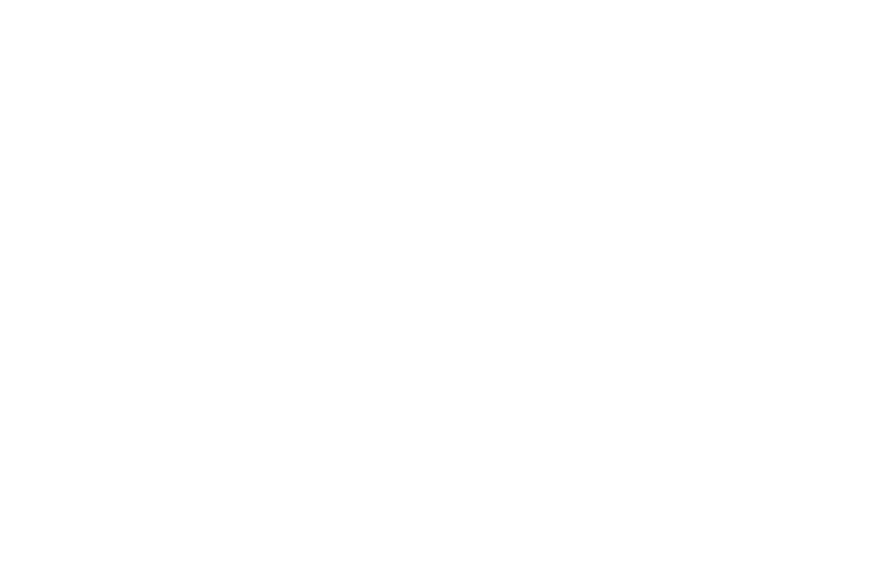

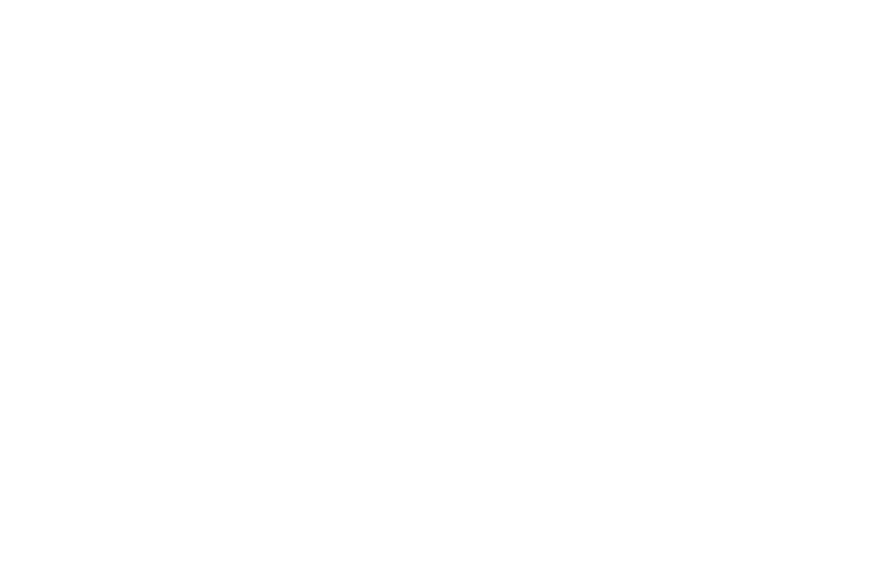

In [7]:
w_sm  = widgets.Dropdown(options=asn_months, description="Month:",
                          layout=widgets.Layout(width="250px"))
w_sc  = widgets.Dropdown(options=[],         description="Country:",
                          layout=widgets.Layout(width="200px"))
w_sms = widgets.IntSlider(value=100, min=10, max=2000, step=50,
                           description="Min samples:", layout=widgets.Layout(width="380px"))
out_s = widgets.Output()

def on_sm(change):
    prev = w_sc.value
    dl, _ = _load_asn(change["new"])
    cc = sorted(dl["country_code"].dropna().unique())
    w_sc.options = [(cc_label(c), c) for c in cc]
    w_sc.value = prev if prev in cc else ("US" if "US" in cc else cc[0])
    draw_s()

def draw_s(change=None):
    dl, _ = _load_asn(w_sm.value)
    df = dl[(dl["country_code"]==w_sc.value) & (dl["sample_count"]>=w_sms.value)].copy()
    df["asn_label"] = df["asn"].apply(asn_label)
    with out_s:
        clear_output(wait=True)
        if df.empty: print("No data. Lower min samples."); return
        fig, ax = plt.subplots(figsize=(9,6))
        sc_plot = ax.scatter(df["sample_count"], df["download_p50"],
                             c=df["latency_p50"], cmap="RdYlGn_r", alpha=0.7,
                             edgecolors="white", linewidths=0.4, s=80)
        plt.colorbar(sc_plot, ax=ax, label="Median latency (ms)")
        ax.set_xscale("log")
        # Override the default log formatter (which generates $10^n$ math text
        # and can crash tight_layout on some backends) with plain numbers.
        ax.xaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
        # Annotate largest ISPs by sample count
        for _, row in df.nlargest(8, "sample_count").iterrows():
            ax.annotate(row["asn_label"], (row["sample_count"], row["download_p50"]),
                        fontsize=6.5, alpha=0.8,
                        xytext=(4, 2), textcoords="offset points")
        ax.set_xlabel("Sample count (log scale)"); ax.set_ylabel("Median download (Mbit/s)")
        ax.set_title(f"ISP quality vs scale — {cc_name(w_sc.value)} ({w_sc.value}) — {w_sm.value}\n"
                     "Colour = latency (green=low); largest ISPs labelled")
        plt.tight_layout(); plt.show()

w_sm.observe(on_sm,"value"); w_sc.observe(draw_s,"value"); w_sms.observe(draw_s,"value")
display(widgets.VBox([widgets.HBox([w_sm,w_sc]), w_sms, out_s]))
on_sm({"new": asn_months[0]})